In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv(r"C:\Users\aparn\OneDrive\Desktop\mlops_project\Data\archive\creditcard.csv")

In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.shape

(284807, 31)

In [6]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

### Note: Imbalanced Dataset
#### If we train a model, Model can '0' for everything.

In [7]:
492/284315*100

0.17304750013189596

##### TO SOlVE Imbalanced Dataset issue

 - Resampling Technique -  Oversampling

##### Explore the Dataset

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [9]:
# Checking the Null Values
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [10]:
df.isnull().any().sum()

np.int64(0)

In [11]:
# Checking Duplicates in the Dataset
df[df.duplicated()]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
113,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
114,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
115,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
282987,171288.0,1.912550,-0.455240,-1.750654,0.454324,2.089130,4.160019,-0.881302,1.081750,1.022928,...,-0.524067,-1.337510,0.473943,0.616683,-0.283548,-1.084843,0.073133,-0.036020,11.99,0
283483,171627.0,-1.464380,1.368119,0.815992,-0.601282,-0.689115,-0.487154,-0.303778,0.884953,0.054065,...,0.287217,0.947825,-0.218773,0.082926,0.044127,0.639270,0.213565,0.119251,6.82,0
283485,171627.0,-1.457978,1.378203,0.811515,-0.603760,-0.711883,-0.471672,-0.282535,0.880654,0.052808,...,0.284205,0.949659,-0.216949,0.083250,0.044944,0.639933,0.219432,0.116772,11.93,0
284191,172233.0,-2.667936,3.160505,-3.355984,1.007845,-0.377397,-0.109730,-0.667233,2.309700,-1.639306,...,0.391483,0.266536,-0.079853,-0.096395,0.086719,-0.451128,-1.183743,-0.222200,55.66,0


In [12]:
# Removing the Duplicate rows
df.drop_duplicates(inplace=True)

In [13]:
# Validating if Duplicate rows are found.
df[df.duplicated()]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class


In [14]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [15]:
pd.set_option('display.max_columns',None)

In [16]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [17]:
timeAnalysis = df[['Time','Amount','Class']].copy()

In [18]:
timeAnalysis.describe()

,Time,Amount,Class
count,283726.000000,283726.000000,283726.000000
mean,94811.077600,88.472687,0.001667
std,47481.047891,250.399437,0.040796
min,0.000000,0.000000,0.000000
25%,54204.750000,5.600000,0.000000
50%,84692.500000,22.000000,0.000000
75%,139298.000000,77.510000,0.000000
max,172792.000000,25691.160000,1.000000


In [19]:
import datetime
datetime.datetime.fromtimestamp(172792.000000)

datetime.datetime(1970, 1, 3, 5, 29, 52)

In [20]:
# Time conversion function
def convert_to_time(seconds):
    return datetime.datetime.fromtimestamp(seconds)

In [21]:
timeAnalysis['datetime'] = timeAnalysis.Time.apply(convert_to_time)

In [22]:
timeAnalysis

,Time,Amount,Class,datetime
0,0.0,149.62,0,1970-01-01 05:30:00
1,0.0,2.69,0,1970-01-01 05:30:00
2,1.0,378.66,0,1970-01-01 05:30:01
3,1.0,123.50,0,1970-01-01 05:30:01
4,2.0,69.99,0,1970-01-01 05:30:02
...,...,...,...,...
284802,172786.0,0.77,0,1970-01-03 05:29:46
284803,172787.0,24.79,0,1970-01-03 05:29:47
284804,172788.0,67.88,0,1970-01-03 05:29:48
284805,172788.0,10.00,0,1970-01-03 05:29:48


In [23]:
timeAnalysis.datetime

0        1970-01-01 05:30:00
1        1970-01-01 05:30:00
2        1970-01-01 05:30:01
3        1970-01-01 05:30:01
4        1970-01-01 05:30:02
                 ...        
284802   1970-01-03 05:29:46
284803   1970-01-03 05:29:47
284804   1970-01-03 05:29:48
284805   1970-01-03 05:29:48
284806   1970-01-03 05:29:52
Name: datetime, Length: 283726, dtype: datetime64[us]

In [24]:
timeAnalysis.datetime.dt.date

0         1970-01-01
1         1970-01-01
2         1970-01-01
3         1970-01-01
4         1970-01-01
             ...    
284802    1970-01-03
284803    1970-01-03
284804    1970-01-03
284805    1970-01-03
284806    1970-01-03
Name: datetime, Length: 283726, dtype: object

In [25]:
start_datetime = timeAnalysis.datetime.min()
start_datetime

Timestamp('1970-01-01 05:30:00')

In [26]:
end_datetime = timeAnalysis.datetime.max()

In [27]:
print(f"Start Date and Time: {start_datetime}")
print(f"End Date and Time: {end_datetime}")

Start Date and Time: 1970-01-01 05:30:00
End Date and Time: 1970-01-03 05:29:52


In [28]:
start_datetime - end_datetime

Timedelta('-2 days +00:00:08')

In [29]:
# Since it is 2 days of Dataset (48 hours)
# We can plot using hours 
timeAnalysis['hour_of_the_day'] = timeAnalysis.datetime.dt.hour

In [30]:
# Applying groupby function based on the Class Column & Hours
timeAnalysisgroupby = timeAnalysis.groupby(['Class','hour_of_the_day'])['Amount'].count()
timeAnalysisgroupby

Class  hour_of_the_day
0      0                  16686
       1                  15920
       2                  17390
       3                  17237
       4                  12828
       5                   9403
       6                   5690
       7                   3045
       8                   4174
       9                   2499
       10                  2075
       11                  3452
       12                  5492
       13                  8542
       14                 13314
       15                 16323
       16                 16712
       17                 16389
       18                 14966
       19                 15801
       20                 16710
       21                 16039
       22                 16569
       23                 15997
1      0                     24
       1                     15
       2                     25
       3                      9
       4                     10
       5                     14
       6         

In [31]:
import matplotlib.pyplot as plt

<Axes: title={'center': 'No. of Credit Card Transactions Per Hour'}, xlabel='hour_of_the_day'>

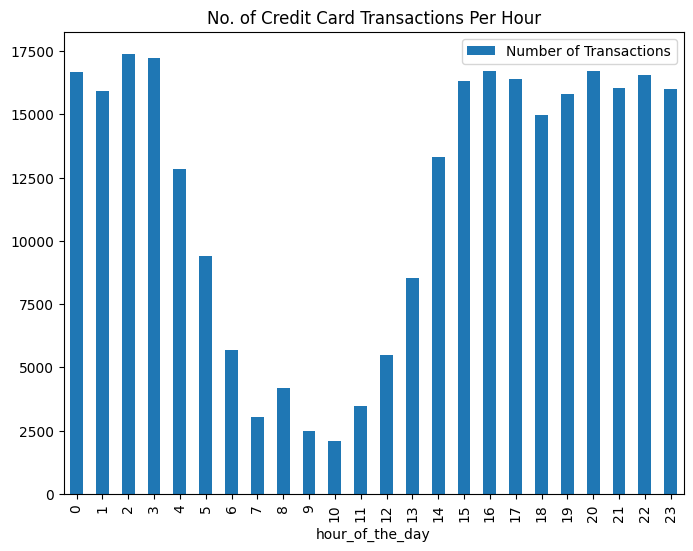

In [32]:
plt.figure(figsize=(8,6))

# Transaction in hours
transactions = timeAnalysisgroupby[0].copy()

# Count of the Transactions
transactions.name = 'Number of Transactions'

# Plotting based on Transactions based on Hours
transactions.plot.bar(title="No. of Credit Card Transactions Per Hour", legend=True)

<Axes: title={'center': 'No. of Credit Card Transactions Per Hour'}, xlabel='hour_of_the_day'>

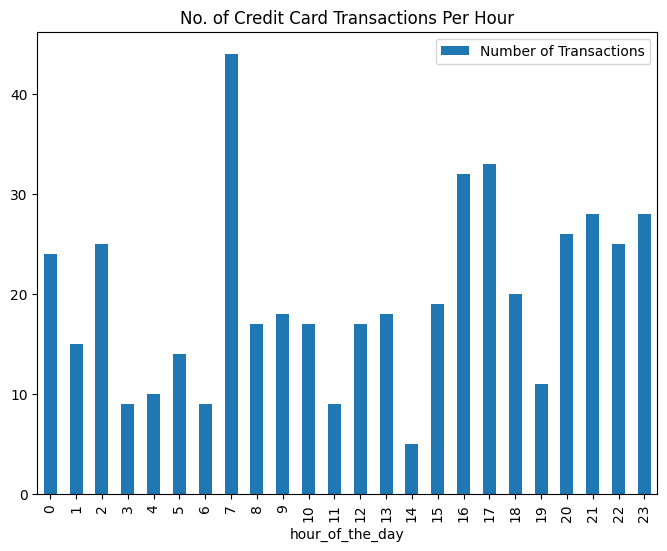

In [33]:
plt.figure(figsize=(8,6))

# Transaction in hours
transactions = timeAnalysisgroupby[1].copy()

# Count of the Transactions
transactions.name = 'Number of Transactions'

# Plotting based on Transactions based on Hours
transactions.plot.bar(title="No. of Credit Card Transactions Per Hour", legend=True)

In [34]:
timeAnalysisgroupby[0]

hour_of_the_day
0     16686
1     15920
2     17390
3     17237
4     12828
5      9403
6      5690
7      3045
8      4174
9      2499
10     2075
11     3452
12     5492
13     8542
14    13314
15    16323
16    16712
17    16389
18    14966
19    15801
20    16710
21    16039
22    16569
23    15997
Name: Amount, dtype: int64

In [35]:
timeAnalysisgroupby[1]

hour_of_the_day
0     24
1     15
2     25
3      9
4     10
5     14
6      9
7     44
8     17
9     18
10    17
11     9
12    17
13    18
14     5
15    19
16    32
17    33
18    20
19    11
20    26
21    28
22    25
23    28
Name: Amount, dtype: int64

In [36]:
timeAnalysisgroupby

Class  hour_of_the_day
0      0                  16686
       1                  15920
       2                  17390
       3                  17237
       4                  12828
       5                   9403
       6                   5690
       7                   3045
       8                   4174
       9                   2499
       10                  2075
       11                  3452
       12                  5492
       13                  8542
       14                 13314
       15                 16323
       16                 16712
       17                 16389
       18                 14966
       19                 15801
       20                 16710
       21                 16039
       22                 16569
       23                 15997
1      0                     24
       1                     15
       2                     25
       3                      9
       4                     10
       5                     14
       6         

### Checking Valid Transactions

<Axes: title={'center': 'Valid Transactions'}, ylabel='Frequency'>

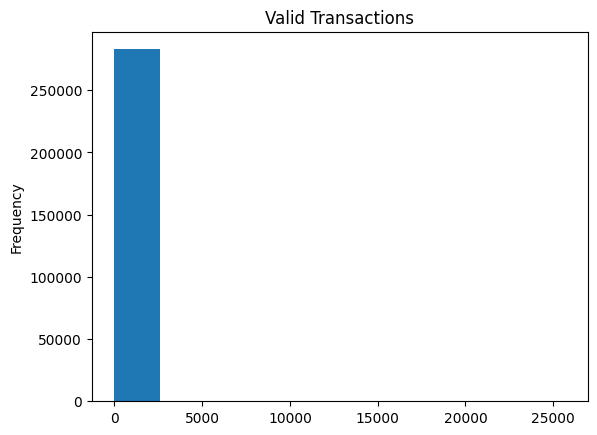

In [37]:
timeAnalysis[timeAnalysis.Class == 0].Amount.plot.hist(title="Valid Transactions")

In [38]:
timeAnalysis[timeAnalysis.Class == 0]

,Time,Amount,Class,datetime,hour_of_the_day
0,0.0,149.62,0,1970-01-01 05:30:00,5
1,0.0,2.69,0,1970-01-01 05:30:00,5
2,1.0,378.66,0,1970-01-01 05:30:01,5
3,1.0,123.50,0,1970-01-01 05:30:01,5
4,2.0,69.99,0,1970-01-01 05:30:02,5
...,...,...,...,...,...
284802,172786.0,0.77,0,1970-01-03 05:29:46,5
284803,172787.0,24.79,0,1970-01-03 05:29:47,5
284804,172788.0,67.88,0,1970-01-03 05:29:48,5
284805,172788.0,10.00,0,1970-01-03 05:29:48,5


In [39]:
# Since Most of the Transactions falls b/w 0 to 2.5k, We will try to add Treshold.

<Axes: title={'center': 'Valid Transaction (Amount Lesser than 4000)'}, ylabel='Frequency'>

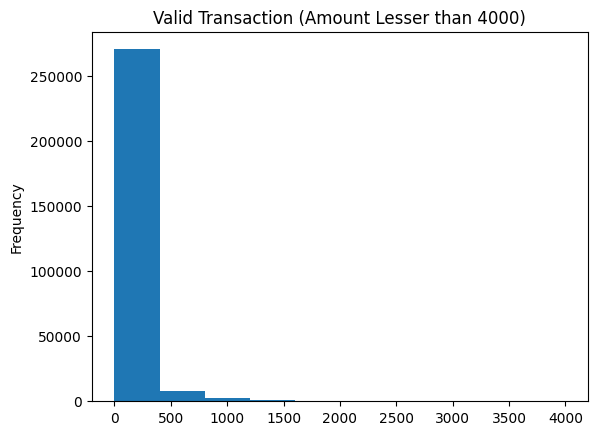

In [40]:
timeAnalysis[(timeAnalysis.Class==0) & (timeAnalysis.Amount <= 4000)].Amount.plot.hist(title="Valid Transaction (Amount Lesser than 4000)")

### Checking Fradulent Transactions

<Axes: title={'center': 'Valid Transactions'}, ylabel='Frequency'>

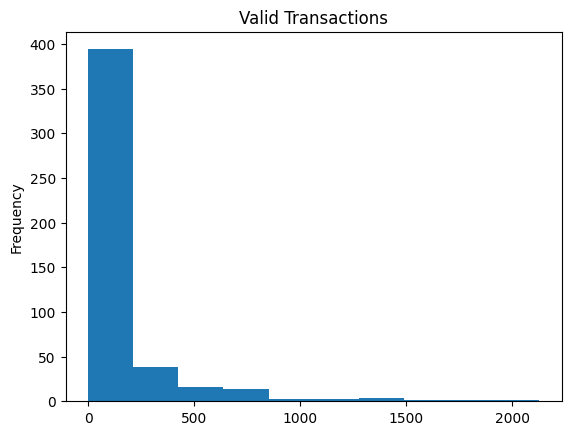

In [41]:
timeAnalysis[timeAnalysis.Class == 1].Amount.plot.hist(title="Valid Transactions")

#### Assignment
  ##### Extend the EDA